In [1]:
import json
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np

### Read and Pre-process Data

In [2]:
meta_filename = '../data/LTE_downlink_806MHz_2022-04-09_30720ksps.sigmf-meta'

with open(meta_filename, 'r') as f:
    meta_data = json.load(f)
    
data_type = meta_data['global']['core:datatype']
Fs = meta_data['global']['core:sample_rate']

In [3]:
if data_type == 'cf32_le':
    dtype = np.complex64
elif data_type == 'ci16_le':
    dtype = np.int16
elif data_type == 'ci8_le':
    dtype = np.int8
else:
    raise ValueError(f"Unsupported data type: {data_type}")

In [4]:
data_filename = '../data/LTE_downlink_806MHz_2022-04-09_30720ksps.sigmf-data'

with open(data_filename, 'rb') as f:
    tmp = np.fromfile(f,dtype=dtype)
    
scale = 2**(-15)
rx = scale*tmp[0::2] + scale*1j*tmp[1::2]

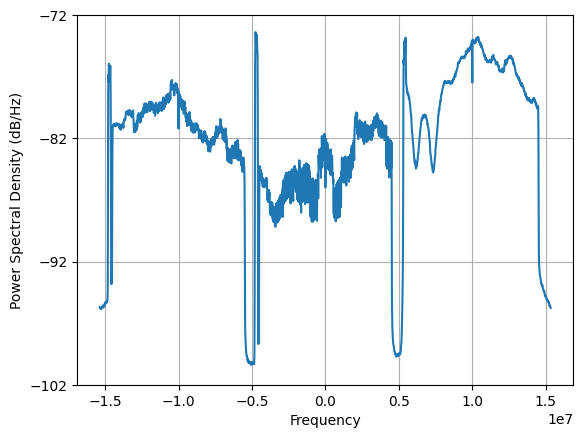

In [5]:
Pxx, ff = plt.psd(rx[:], Fs=Fs, NFFT=2048)
plt.show()

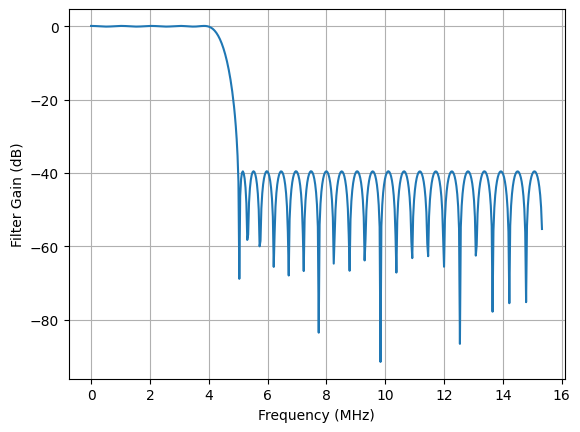

In [6]:
h = signal.remez(60, [0, 4e6, 5e6, Fs/2], [1, 0], fs=Fs)
w, H = signal.freqz(h, fs=Fs)

plt.plot(w/1e6, 20*np.log10(np.abs(H)))
plt.grid()
plt.xlabel('Frequency (MHz)')
plt.ylabel('Filter Gain (dB)')
plt.show()

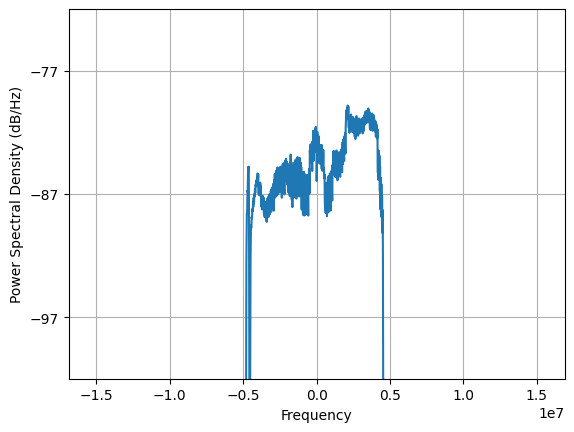

In [7]:
rx = np.convolve(rx, h)
Pxx, ff = plt.psd(rx, Fs=Fs, NFFT=2048)
plt.ylim(-102, -72)
plt.show()

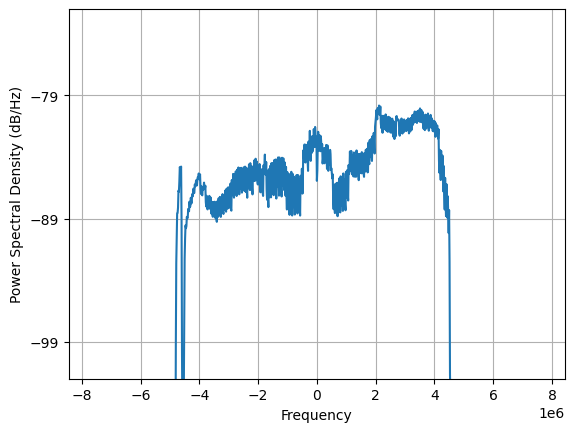

In [8]:
## Down-sample the signal by a factor of 2
rxf = rx[::2]
Fs = Fs/2

df_sc = 15e3
N_FFT = int(Fs / df_sc)
N_CP = 144 // (2048 // N_FFT)
N_CP_extra = 16 // (2048 // N_FFT)
N_subframe = int(Fs * 1e-3)

Pxx, ff = plt.psd(rxf, Fs=Fs, NFFT=N_FFT)
plt.ylim(-102, -72)
plt.show()

In [9]:
import sys
sys.path.insert(0, '../include')
sys.path.insert(0, '../data')

from lte_system_info import LTEParams
from protected_circular_buffer import CircularBuffer
from cell_search import PSSDetection, SSSDetection, PSSChunk
from crs_estimate import CRSChannelEstimation, c_sequence
from mib_decode import PBCHDecoding, BCHDecoding, MIBChunk, equalize_2ant
from sib1_decode_control import PCFICHDecoding, PDCCHDecoding

class SIB1Chunk:
    def __init__(self, data, tag, N_id, N_rb, ns, f_d, n_ant,
                 phich_res, sfn, n_symbols=14, is_slot_start=True):
        N_sc = N_rb * 12
        self.data = data
        self.tag = tag
        self.N_id = N_id
        self.N_rb = N_rb
        self.N_sc = N_sc
        self.ns = ns
        self.f_d = f_d
        self.n_symbols = n_symbols
        self.is_slot_start = is_slot_start
        self.n_ant = n_ant
        self.phich_res = phich_res
        self.sfn = sfn
        self.symbols = np.zeros((n_symbols, N_sc), dtype=complex)
        self.H = np.zeros((4, n_symbols, N_sc), dtype=complex)
        self.cfi = None
        self.cfi_hamming = None
        self.dci_decoded = False
        self.dci_cost = None
        self.rb_start = None
        self.L_crbs = None
        self.Q_m = None
        self.rv = None
        self.tbs = None

In [10]:
Fs = float(np.load('../data/Fs.npy'))
params = LTEParams(Fs=Fs)

In [11]:
stride = params.stride

In [12]:
buf = CircularBuffer(len(rxf))
buf.write(rxf)

pss = PSSDetection(params, peak_ratio=5.0)

pos = 0
chunk_id = 0
pss_count = 0

while pos + params.N_subframe <= len(rxf):
    pid = buf.protect(pos, params.N_subframe)
    data = buf.read_protected(pid)
    buf.release(pid)

    chunk = pss(PSSChunk(data, chunk_id))

    if chunk.pss_detected:
        pss_count += 1
        global_pss = pos + chunk.pss_local_index
        print(f"Chunk {chunk_id}: PSS detected | "
              f"N_id_2={chunk.N_id_2}, "
              f"local={chunk.pss_local_index}, global={global_pss}")

    pos += stride
    chunk_id += 1

print(f"\nScanned {chunk_id} chunks, {pss_count} PSS detected")

Chunk 0: PSS detected | N_id_2=2, local=12309, global=12309
Chunk 2: PSS detected | N_id_2=2, local=9563, global=36043
Chunk 6: PSS detected | N_id_2=2, local=9667, global=89107
Chunk 8: PSS detected | N_id_2=2, local=6922, global=112842
Chunk 12: PSS detected | N_id_2=2, local=7027, global=165907
Chunk 13: PSS detected | N_id_2=0, local=11192, global=183312
Chunk 14: PSS detected | N_id_2=2, local=4283, global=189643
Chunk 18: PSS detected | N_id_2=2, local=4390, global=242710
Chunk 19: PSS detected | N_id_2=2, local=14327, global=265887
Chunk 20: PSS detected | N_id_2=2, local=1642, global=266442
Chunk 22: PSS detected | N_id_2=2, local=14330, global=305610
Chunk 24: PSS detected | N_id_2=2, local=1746, global=319506
Chunk 25: PSS detected | N_id_2=2, local=12243, global=343243
Chunk 26: PSS detected | N_id_2=1, local=2587, global=346827
Chunk 29: PSS detected | N_id_2=2, local=12349, global=396309
Chunk 31: PSS detected | N_id_2=2, local=9602, global=420042
Chunk 35: PSS detected | 

In [13]:
buf = CircularBuffer(len(rxf))
buf.write(rxf)

pss = PSSDetection(params, peak_ratio=5.0)
sss = SSSDetection(params, peak_ratio=8.0)

pos = 0
chunk_id = 0
cells = []

while pos + params.N_subframe <= len(rxf):
    pid = buf.protect(pos, params.N_subframe)
    data = buf.read_protected(pid)
    buf.release(pid)

    chunk = sss(pss(PSSChunk(data, chunk_id)))

    if chunk.pss_detected and chunk.sss_detected:
        N_id = 3 * chunk.N_id_1 + chunk.N_id_2
        cells.append({
            'tag': chunk_id, 'pos': pos,
            'N_id': N_id, 'N_id_1': chunk.N_id_1, 'N_id_2': chunk.N_id_2,
            'F': chunk.F, 'pss_local_index': chunk.pss_local_index,
            'f_d': chunk.f_d
        })
        global_pss = pos + chunk.pss_local_index
        print(f"Chunk {chunk_id}: PCI={N_id} | "
              f"F={chunk.F}, global={global_pss} | f_d={chunk.f_d:.1f} Hz")

    pos += stride
    chunk_id += 1

print(f"\nScanned {chunk_id} chunks, {len(cells)} cells found")

Chunk 2: PCI=380 | F=0, global=36043 | f_d=1126.9 Hz
Chunk 8: PCI=380 | F=1, global=112842 | f_d=1128.4 Hz
Chunk 14: PCI=380 | F=0, global=189643 | f_d=1164.2 Hz
Chunk 20: PCI=380 | F=1, global=266442 | f_d=1204.1 Hz
Chunk 25: PCI=380 | F=0, global=343243 | f_d=1180.9 Hz
Chunk 31: PCI=380 | F=1, global=420042 | f_d=1107.1 Hz
Chunk 37: PCI=380 | F=0, global=496842 | f_d=1179.5 Hz
Chunk 43: PCI=380 | F=1, global=573643 | f_d=1142.0 Hz
Chunk 49: PCI=380 | F=0, global=650441 | f_d=1269.2 Hz
Chunk 54: PCI=380 | F=1, global=727242 | f_d=1165.1 Hz
Chunk 60: PCI=380 | F=0, global=804042 | f_d=1122.2 Hz
Chunk 66: PCI=380 | F=1, global=880841 | f_d=1118.7 Hz
Chunk 72: PCI=380 | F=0, global=957642 | f_d=1144.7 Hz
Chunk 78: PCI=380 | F=1, global=1034441 | f_d=1243.3 Hz
Chunk 83: PCI=380 | F=0, global=1111242 | f_d=1161.0 Hz
Chunk 89: PCI=380 | F=1, global=1188041 | f_d=1385.2 Hz
Chunk 95: PCI=380 | F=0, global=1264841 | f_d=1213.6 Hz
Chunk 101: PCI=380 | F=1, global=1341642 | f_d=1145.6 Hz
Chunk 1

In [14]:
crs_mib = CRSChannelEstimation(params)
crs_mib.config(N_id=cells[0]['N_id'], N_rb=6, ns=1, n_symbols=4, is_slot_start=True)

pbch = PBCHDecoding()
pbch.config(N_id=cells[0]['N_id'])

bch = BCHDecoding()
bch.config(N_id=cells[0]['N_id'])

for n in range(0, len(cells), 2):
    cell = cells[n]
    N_id = cell['N_id']
    F = cell['F']
    f_d = cell['f_d']
    first_pss_global = cell['pos'] + cell['pss_local_index']

    print("=" * 50)
    print(f"Cell #{n}: PCI={N_id}, F={F}, f_d={f_d:.1f} Hz")

    slot1_start = first_pss_global + params.N_FFT - F * params.N_half_frame

    pid = buf.protect(slot1_start, params.pbch_len)
    data = buf.read_protected(pid)
    buf.release(pid)

    chunk = MIBChunk(data, tag=n, N_id=N_id, f_d=f_d)
    crs_mib(chunk)

    for n_ant in [1, 2, 4]:
        chunk.n_ant = n_ant
        pbch(chunk)
        bch(chunk)
        if chunk.mib_decoded:
            print(f"  MIB decoded (n_ant={n_ant})")
            print(f"  BW={chunk.dl_bw}, SFN={chunk.sfn}, "
                  f"PHICH_dur={chunk.phich_dur}, PHICH_res={chunk.phich_res}")
            break

    if not chunk.mib_decoded:
        print(f"  FAILED")

print("=" * 50)

Cell #0: PCI=380, F=0, f_d=1126.9 Hz
  MIB decoded (n_ant=2)
  BW=50, SFN=313, PHICH_dur=normal, PHICH_res=1
Cell #2: PCI=380, F=0, f_d=1164.2 Hz
  MIB decoded (n_ant=2)
  BW=50, SFN=314, PHICH_dur=normal, PHICH_res=1
Cell #4: PCI=380, F=0, f_d=1180.9 Hz
  MIB decoded (n_ant=2)
  BW=50, SFN=315, PHICH_dur=normal, PHICH_res=1
Cell #6: PCI=380, F=0, f_d=1179.5 Hz
  MIB decoded (n_ant=2)
  BW=50, SFN=316, PHICH_dur=normal, PHICH_res=1
Cell #8: PCI=380, F=0, f_d=1269.2 Hz
  MIB decoded (n_ant=2)
  BW=50, SFN=317, PHICH_dur=normal, PHICH_res=1
Cell #10: PCI=380, F=0, f_d=1122.2 Hz
  MIB decoded (n_ant=2)
  BW=50, SFN=318, PHICH_dur=normal, PHICH_res=1
Cell #12: PCI=380, F=0, f_d=1144.7 Hz
  MIB decoded (n_ant=2)
  BW=50, SFN=319, PHICH_dur=normal, PHICH_res=1
Cell #14: PCI=380, F=0, f_d=1161.0 Hz
  MIB decoded (n_ant=2)
  BW=50, SFN=320, PHICH_dur=normal, PHICH_res=1
Cell #16: PCI=380, F=0, f_d=1213.6 Hz
  MIB decoded (n_ant=2)
  BW=50, SFN=321, PHICH_dur=normal, PHICH_res=1
Cell #18: PCI=3

In [15]:
crs_sib = CRSChannelEstimation(params)
pcfich_func = PCFICHDecoding()

print("CFI across SIB1-eligible subframes:\n")

for n in range(2, len(cells), 4):
    cell = cells[n]
    N_id = cell['N_id']
    F = cell['F']
    f_d = cell['f_d']
    first_pss_global = cell['pos'] + cell['pss_local_index']

    slot1_start = first_pss_global + params.N_FFT - F * params.N_half_frame

    pid = buf.protect(slot1_start, params.pbch_len)
    data = buf.read_protected(pid)
    buf.release(pid)

    mib_chunk = MIBChunk(data, tag=n, N_id=N_id, f_d=f_d)
    crs_mib(mib_chunk)
    for n_ant in [1, 2, 4]:
        mib_chunk.n_ant = n_ant
        pbch(mib_chunk)
        bch(mib_chunk)
        if mib_chunk.mib_decoded:
            break
    if not mib_chunk.mib_decoded:
        continue

    frame_start = slot1_start - params.N_slot
    subf5_start = frame_start + 5 * params.N_subframe

    pid = buf.protect(subf5_start, params.N_subframe)
    data = buf.read_protected(pid)
    buf.release(pid)

    sib_chunk = SIB1Chunk(data, tag=n, N_id=N_id, N_rb=mib_chunk.dl_bw,
                          ns=10, f_d=f_d, n_ant=mib_chunk.n_ant,
                          phich_res=mib_chunk.phich_res, sfn=mib_chunk.sfn)

    crs_sib.config(N_id=N_id, N_rb=mib_chunk.dl_bw, ns=10, n_symbols=14, is_slot_start=True)
    crs_sib(sib_chunk)

    pcfich_func.config(N_id=N_id, N_rb=mib_chunk.dl_bw, ns=10)
    pcfich_func(sib_chunk)

    print(f"cells[{n:3d}] SFN={mib_chunk.sfn} CFI={sib_chunk.cfi} hamming={sib_chunk.cfi_hamming}")

CFI across SIB1-eligible subframes:

cells[  2] SFN=314 CFI=1 hamming=0
cells[  6] SFN=316 CFI=1 hamming=0
cells[ 10] SFN=318 CFI=1 hamming=0
cells[ 14] SFN=320 CFI=1 hamming=0
cells[ 18] SFN=322 CFI=1 hamming=0
cells[ 22] SFN=324 CFI=1 hamming=0
cells[ 26] SFN=326 CFI=2 hamming=0
cells[ 30] SFN=328 CFI=2 hamming=0
cells[ 34] SFN=330 CFI=2 hamming=0
cells[ 38] SFN=332 CFI=2 hamming=0
cells[ 42] SFN=334 CFI=2 hamming=0
cells[ 46] SFN=336 CFI=2 hamming=0
cells[ 50] SFN=338 CFI=2 hamming=0
cells[ 54] SFN=340 CFI=2 hamming=0
cells[ 58] SFN=342 CFI=2 hamming=0
cells[ 62] SFN=344 CFI=2 hamming=0
cells[ 66] SFN=346 CFI=2 hamming=0
cells[ 70] SFN=348 CFI=2 hamming=0
cells[ 74] SFN=350 CFI=2 hamming=0
cells[ 78] SFN=352 CFI=2 hamming=0
cells[ 82] SFN=354 CFI=2 hamming=0
cells[ 86] SFN=356 CFI=1 hamming=1
cells[ 90] SFN=358 CFI=1 hamming=2
cells[ 94] SFN=360 CFI=1 hamming=0
cells[ 98] SFN=362 CFI=1 hamming=0
cells[102] SFN=364 CFI=1 hamming=0
cells[106] SFN=366 CFI=2 hamming=2
cells[110] SFN=368

In [16]:
pdcch_func = PDCCHDecoding()

print("PDCCH across SIB1-eligible subframes:\n")

for n in range(2, len(cells), 4):
    cell = cells[n]
    N_id = cell['N_id']
    F = cell['F']
    f_d = cell['f_d']
    first_pss_global = cell['pos'] + cell['pss_local_index']

    slot1_start = first_pss_global + params.N_FFT - F * params.N_half_frame

    pid = buf.protect(slot1_start, params.pbch_len)
    data = buf.read_protected(pid)
    buf.release(pid)

    mib_chunk = MIBChunk(data, tag=n, N_id=N_id, f_d=f_d)
    crs_mib(mib_chunk)
    for n_ant in [1, 2, 4]:
        mib_chunk.n_ant = n_ant
        pbch(mib_chunk)
        bch(mib_chunk)
        if mib_chunk.mib_decoded:
            break
    if not mib_chunk.mib_decoded:
        continue

    frame_start = slot1_start - params.N_slot
    subf5_start = frame_start + 5 * params.N_subframe

    pid = buf.protect(subf5_start, params.N_subframe)
    data = buf.read_protected(pid)
    buf.release(pid)

    sib_chunk = SIB1Chunk(data, tag=n, N_id=N_id, N_rb=mib_chunk.dl_bw,
                          ns=10, f_d=f_d, n_ant=mib_chunk.n_ant,
                          phich_res=mib_chunk.phich_res, sfn=mib_chunk.sfn)

    crs_sib.config(N_id=N_id, N_rb=mib_chunk.dl_bw, ns=10, n_symbols=14, is_slot_start=True)
    crs_sib(sib_chunk)

    pcfich_func.config(N_id=N_id, N_rb=mib_chunk.dl_bw, ns=10)
    pcfich_func(sib_chunk)

    pdcch_func.config(N_id=N_id, N_rb=mib_chunk.dl_bw, n_ant=mib_chunk.n_ant,
                      phich_res=mib_chunk.phich_res, ns=10)
    pdcch_func(sib_chunk)

    if sib_chunk.dci_decoded:
        print(f"cells[{n:3d}] SFN={mib_chunk.sfn} CFI={sib_chunk.cfi} "
              f"rb={sib_chunk.rb_start} L={sib_chunk.L_crbs} "
              f"Qm={sib_chunk.Q_m} rv={sib_chunk.rv} TBS={sib_chunk.tbs}")
    else:
        print(f"cells[{n:3d}] SFN={mib_chunk.sfn} CFI={sib_chunk.cfi} DCI not found")

PDCCH across SIB1-eligible subframes:

cells[  2] SFN=314 CFI=1 rb=0 L=4 Qm=2 rv=2 TBS=176
cells[  6] SFN=316 CFI=1 rb=0 L=4 Qm=2 rv=3 TBS=176
cells[ 10] SFN=318 CFI=1 rb=0 L=4 Qm=2 rv=1 TBS=176
cells[ 14] SFN=320 CFI=1 rb=0 L=4 Qm=2 rv=0 TBS=176
cells[ 18] SFN=322 CFI=1 rb=0 L=4 Qm=2 rv=2 TBS=176
cells[ 22] SFN=324 CFI=1 rb=0 L=4 Qm=2 rv=3 TBS=176
cells[ 26] SFN=326 CFI=2 rb=0 L=4 Qm=2 rv=1 TBS=176
cells[ 30] SFN=328 CFI=2 rb=0 L=4 Qm=2 rv=0 TBS=176
cells[ 34] SFN=330 CFI=2 rb=0 L=4 Qm=2 rv=2 TBS=176
cells[ 38] SFN=332 CFI=2 rb=0 L=4 Qm=2 rv=3 TBS=176
cells[ 42] SFN=334 CFI=2 rb=0 L=4 Qm=2 rv=1 TBS=176
cells[ 46] SFN=336 CFI=2 rb=0 L=4 Qm=2 rv=0 TBS=176
cells[ 50] SFN=338 CFI=2 rb=0 L=4 Qm=2 rv=2 TBS=176
cells[ 54] SFN=340 CFI=2 rb=0 L=4 Qm=2 rv=3 TBS=176
cells[ 58] SFN=342 CFI=2 rb=0 L=4 Qm=2 rv=1 TBS=176
cells[ 62] SFN=344 CFI=2 rb=0 L=4 Qm=2 rv=0 TBS=176
cells[ 66] SFN=346 CFI=2 rb=0 L=4 Qm=2 rv=2 TBS=176
cells[ 70] SFN=348 CFI=2 rb=0 L=4 Qm=2 rv=3 TBS=176
cells[ 74] SFN=350 CFI=2 

In [17]:
# PDSCH decoding for a single frame

n_cell = 138

cell = cells[n_cell]
N_id = cell['N_id']
F = cell['F']
f_d = cell['f_d']
first_pss_global = cell['pos'] + cell['pss_local_index']
print("=" * 60)
print(f"Cell #{n_cell}: PCI={N_id}, F={F}, f_d={f_d:.1f} Hz")

slot1_start = first_pss_global + params.N_FFT - F * params.N_half_frame

pid = buf.protect(slot1_start, params.pbch_len)
data = buf.read_protected(pid)
buf.release(pid)

mib_chunk = MIBChunk(data, tag=0, N_id=N_id, f_d=f_d)
crs_mib(mib_chunk)
for n_ant in [1, 2, 4]:
    mib_chunk.n_ant = n_ant
    pbch(mib_chunk)
    bch(mib_chunk)
    if mib_chunk.mib_decoded:
        break

assert mib_chunk.mib_decoded
print(f"MIB: BW={mib_chunk.dl_bw}, n_ant={mib_chunk.n_ant}, "
      f"SFN={mib_chunk.sfn}, PHICH_res={mib_chunk.phich_res}")

frame_start = slot1_start - params.N_slot
subf5_start = frame_start + 5 * params.N_subframe

pid = buf.protect(subf5_start, params.N_subframe)
data = buf.read_protected(pid)
buf.release(pid)

sib_chunk = SIB1Chunk(data, tag=0, N_id=N_id, N_rb=mib_chunk.dl_bw,
                      ns=10, f_d=f_d, n_ant=mib_chunk.n_ant,
                      phich_res=mib_chunk.phich_res, sfn=mib_chunk.sfn)

crs_sib.config(N_id=N_id, N_rb=mib_chunk.dl_bw, ns=10, n_symbols=14, is_slot_start=True)
crs_sib(sib_chunk)

pcfich_func.config(N_id=N_id, N_rb=mib_chunk.dl_bw, ns=10)
pcfich_func(sib_chunk)

pdcch_func.config(N_id=N_id, N_rb=mib_chunk.dl_bw, n_ant=mib_chunk.n_ant,
                  phich_res=mib_chunk.phich_res, ns=10)
pdcch_func(sib_chunk)

print(f"\nCFI={sib_chunk.cfi} (hamming={sib_chunk.cfi_hamming})")
if sib_chunk.dci_decoded:
    print(f"DCI: rb={sib_chunk.rb_start} L={sib_chunk.L_crbs} "
          f"Qm={sib_chunk.Q_m} rv={sib_chunk.rv} TBS={sib_chunk.tbs}")
else:
    print("DCI not found")

Cell #138: PCI=380, F=0, f_d=911.7 Hz
MIB: BW=50, n_ant=2, SFN=382, PHICH_res=1

CFI=1 (hamming=1)
DCI: rb=0 L=4 Qm=2 rv=1 TBS=176


In [18]:
# PDSCH RE extraction — reads from sib_chunk.symbols, sib_chunk.H

N_id = sib_chunk.N_id
N_rb_dl = sib_chunk.N_rb
CFI = sib_chunk.cfi
rb_start = sib_chunk.rb_start
L_crbs = sib_chunk.L_crbs

nu_shift = N_id % 6
k_start = rb_start * 12
k_end = (rb_start + L_crbs) * 12

crs_syms = {0, 4, 7, 11}

N_sc_pdsch = L_crbs * 12
crs_mask = np.ones(N_sc_pdsch, dtype=bool)
for k in range(N_sc_pdsch):
    if (k_start + k) % 6 in {nu_shift, (nu_shift + 3) % 6}:
        crs_mask[k] = False

print(f"PDSCH: RBs {rb_start}..{rb_start + L_crbs - 1}, "
      f"symbols {CFI}..13")
print(f"CRS excluded at offsets mod 6: {nu_shift}, {(nu_shift+3)%6}")
print(f"REs per symbol: {N_sc_pdsch} total, "
      f"{np.sum(crs_mask)} data (CRS sym), "
      f"{N_sc_pdsch} data (non-CRS sym)")

r_pdsch = np.array([], dtype=complex)
H_pdsch = np.zeros((4, 0), dtype=complex)

for l in range(CFI, 14):
    r_sym = sib_chunk.symbols[l, k_start:k_end]
    H_sym = sib_chunk.H[:, l, k_start:k_end]

    if l in crs_syms:
        r_pdsch = np.concatenate((r_pdsch, r_sym[crs_mask]))
        H_pdsch = np.concatenate((H_pdsch, H_sym[:, crs_mask]), axis=1)
    else:
        r_pdsch = np.concatenate((r_pdsch, r_sym))
        H_pdsch = np.concatenate((H_pdsch, H_sym), axis=1)

print(f"Total PDSCH REs: {len(r_pdsch)}")

PDSCH: RBs 0..3, symbols 1..13
CRS excluded at offsets mod 6: 2, 5
REs per symbol: 48 total, 32 data (CRS sym), 48 data (non-CRS sym)
Total PDSCH REs: 576


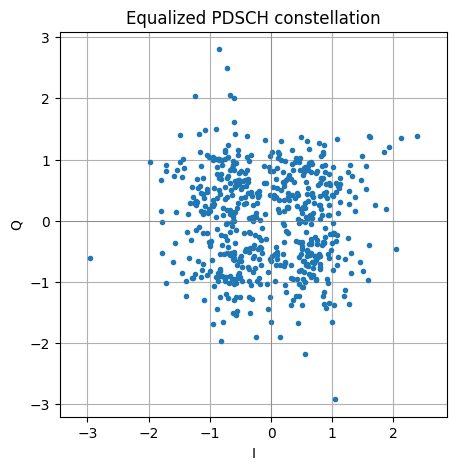

In [19]:
x_pdsch = equalize_2ant(r_pdsch, H_pdsch)

plt.figure(figsize=(5, 5))
plt.plot(x_pdsch.real, x_pdsch.imag, '.')
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.grid(True)
plt.axis('equal')
plt.xlabel('I')
plt.ylabel('Q')
plt.title('Equalized PDSCH constellation')
plt.show()

In [20]:
# soft QPSK demod (preserves magnitude as confidence)
pdsch_scrambled_bits = np.zeros(len(x_pdsch) * 2)
pdsch_scrambled_bits[0::2] = -x_pdsch.real
pdsch_scrambled_bits[1::2] = -x_pdsch.imag

In [21]:
n_RNTI = 0xFFFF
ns = 10
q = 0
c_init = (n_RNTI << 14) + (q << 13) + ((ns // 2) << 9) + N_id

c = c_sequence(len(pdsch_scrambled_bits), c_init)

pdsch_bits = pdsch_scrambled_bits * (1.-2*c)

In [22]:
def rate_matching_turbo(seq, col_perm_table, rv):
    
    C = 32
    D = len(seq)
    
    DUMMY = D+10000

    R = D // C
    if R * C < D:
        R = R + 1
        
    K_pi = R*C
            
    N_dummy = K_pi - D
    y = np.concatenate( (DUMMY *np.ones(N_dummy, dtype=seq.dtype), seq) )
    M = np.reshape(y, (R, C))
    
    # port 1 and 2
    p = np.zeros_like(M)
    for n in range(C):
        p[:, n] = M[:, col_perm_table[n]]
    v1 = np.reshape(p.T, -1)

    # port 3: QPP interleaver
    v3 = np.empty(K_pi, dtype=seq.dtype)
    for k in range(K_pi):
        pi_k = (col_perm_table[k // R] + C * (k % R) + 1) % K_pi
        v3[k] = y[pi_k]

    # combine
    v2 = v1.copy()
    for i in range(K_pi):
        if v2[i] < 10000:
            v2[i] += D
        if v3[i] < 10000:
            v3[i] += 2 * D

    N_cb = 3 * K_pi
    v_comb = np.zeros(N_cb, dtype=seq.dtype)
    v_comb[:K_pi] = v1
    for i in range(K_pi):
        v_comb[K_pi + 2*i] = v2[i]
        v_comb[K_pi + 2*i + 1] = v3[i]

    k0 = R * (2 * int(np.ceil(N_cb / (8.0 * R))) * rv + 2)
    
    e = np.empty(3 * D, dtype=seq.dtype)
    k = 0
    j = 0
    while k < 3 * D:
        idx = (k0 + j) % N_cb
        if v_comb[idx] != DUMMY:
            e[k] = v_comb[idx]
            k += 1
        j += 1
    return e

In [23]:
CRC_len = 24
trellis_end = 4
coded_block_size = sib_chunk.tbs + CRC_len + trellis_end
collect_len = 3 * coded_block_size

ind = np.arange(coded_block_size)
col_perm_table = np.array([0, 16, 8, 24, 4, 20, 12, 28, 2, 18, 10, 26, 6, 22, 14, 30,
                           1, 17, 9, 25, 5, 21, 13, 29, 3, 19, 11, 27, 7, 23, 15, 31])

perm_table = rate_matching_turbo(ind, col_perm_table, sib_chunk.rv)

pdsch_coded_bits = np.zeros(collect_len)
pdsch_coded_bits[perm_table] = pdsch_bits[:collect_len]
pdsch_coded_bits = pdsch_coded_bits.reshape(3, coded_block_size)

In [24]:
def bits_to_LLRs(bits, noise_sigma):
    return -2 * bits / noise_sigma**2

sib1_noise_sigma = 0.3
pdsch_LLR = np.zeros_like(pdsch_coded_bits)

for n in range(3):
    pdsch_LLR[n,:] = bits_to_LLRs(pdsch_coded_bits[n,:], sib1_noise_sigma)

def turbo_len(transport_size):
    pdsch_crc_len = 24
    turbo_tail = 4
    return transport_size + pdsch_crc_len + turbo_tail

In [25]:
def f1f2_table(K):
    return {
        40: (3,10),     48: (7,12),     56: (19,42),    64: (7,16),     72: (7,18),     80: (11,20),
        88: (5,22),     96: (11,24),    104: (7,26),    112: (41,84),   120: (103,90),  128: (15,32),
        136: (9,34),    144: (17,108),  152: (9,38),    160: (21,120),  168: (101,84),  176: (21,44),
        184: (57,46),   192: (23,48),   200: (13,50),   208: (27,52),   216: (11,36),   224: (27,56),
        232: (85,58),   240: (29,60),   248: (33,62),   256: (15,32),   264: (17,198),  272: (33,68),
        280: (103,210), 288: (19,36),   296: (19,74),   304: (37,76),   312: (19,78),   320: (21,120),
        328: (21,82),   336: (115,84),  344: (193,86),  352: (21,44),   360: (133,90),  368: (81,46),
        376: (45,94),   384: (23,48),   392: (243,98),  400: (151,40),  408: (155,102), 416: (25,52),
        424: (51,106),  432: (47,72),   440: (91,110),  448: (29,168),  456: (29,114),  464: (247,58),
        472: (29,118),  480: (89,180),  488: (91,122),  496: (157,62),  504: (55,84),   512: (31,64),
        528: (17,66),   544: (35,68),   560: (227,420), 576: (65,96),   592: (19,74),   608: (37,76),
        624: (41,234),  640: (39,80),   656: (185,82),  672: (43,252),  688: (21,86),   704: (155,44),
        720: (79,120),  736: (139,92),  752: (23,94),   768: (217,48),  784: (25,98),   800: (17,80),
    }[K]

In [26]:
def maxstar(a, b):
    result = np.empty_like(a)
    ainf = a == -np.inf
    binf = b == -np.inf
    result[ainf] = b[ainf]
    result[binf] = a[binf]
    noninf = (a != -np.inf) & (b != -np.inf)
    an = a[noninf]
    bn = b[noninf]
    result[noninf] = np.maximum(an, bn) + np.log1p(np.exp(-np.abs(an-bn)))
    return result

def BCJR(Ru, R, Ap):
    T = Ru.size
    nu = 3
    Ns = 8
    NEG_INF = -1e10

    def log_sigmoid(x):
        return np.where(x >= 0, -np.log1p(np.exp(-x)), x - np.log1p(np.exp(x)))

    gamma = np.full((T, Ns, Ns), NEG_INF)

    K = Ap.size
    for t in range(K):
        for r in range(Ns):
            for s in range(Ns):
                if (r >> 1) == (s & ((2**(nu-1))-1)):
                    feedback = (r ^ (r >> 1)) & 1
                    newbit = (s >> (nu-1)) ^ feedback
                    c0 = newbit
                    c1 = (r ^ (r >> 2) ^ (s >> (nu-1))) & 1
                    gamma[t,r,s] = (log_sigmoid(Ap[t] * (1 - 2*newbit))
                                   + log_sigmoid(Ru[t] * (1 - 2*c0))
                                   + log_sigmoid(R[t] * (1 - 2*c1)))

    for t in range(K, T):
        for r in range(Ns):
            s = r >> 1
            feedback = (r ^ (r >> 1)) & 1
            c0 = feedback
            c1 = (r ^ (r >> 2)) & 1
            gamma[t,r,s] = (log_sigmoid(Ru[t] * (1 - 2*c0))
                           + log_sigmoid(R[t] * (1 - 2*c1)))

    alpha = np.full((T+1, Ns), NEG_INF)
    alpha[0, 0] = 0.0
    for t in range(T):
        for s in range(Ns):
            vals = np.array([alpha[t, r] + gamma[t, r, s] for r in range(Ns)])
            alpha[t+1, s] = vals[0]
            for v in vals[1:]:
                alpha[t+1, s] = maxstar(np.array([alpha[t+1, s]]), np.array([v]))[0]

    beta = np.full((T+1, Ns), NEG_INF)
    beta[T, 0] = 0.0
    for t in range(T-1, -1, -1):
        for r in range(Ns):
            vals = np.array([beta[t+1, s] + gamma[t, r, s] for s in range(Ns)])
            beta[t, r] = vals[0]
            for v in vals[1:]:
                beta[t, r] = maxstar(np.array([beta[t, r]]), np.array([v]))[0]

    Lp = np.full(K, NEG_INF)
    Lm = np.full(K, NEG_INF)

    for t in range(K):
        for r in range(Ns):
            for s in range(Ns):
                if gamma[t,r,s] > NEG_INF:
                    m = alpha[t,r] + gamma[t,r,s] + beta[t+1,s]
                    feedback = (r ^ (r >> 1)) & 1
                    newbit = (s >> (nu-1)) ^ feedback
                    if newbit == 1:
                        Lp[t] = maxstar(np.array([Lp[t]]), np.array([m]))[0]
                    else:
                        Lm[t] = maxstar(np.array([Lm[t]]), np.array([m]))[0]

    return Lm - Lp

def LTE_turbo_decoder(LLRs, TBS, num_iterations=5):
    K = turbo_len(TBS) - 4
    f1, f2 = f1f2_table(K)

    perm = np.array([(f1*i + f2*i*i) % K for i in range(K)])
    perm_inv = np.empty(K, dtype=int)
    perm_inv[perm] = np.arange(K)

    Ru1 = np.concatenate([LLRs[0,:K], [LLRs[0,K], LLRs[2,K], LLRs[1,K+1]]])
    R1  = np.concatenate([LLRs[1,:K], [LLRs[1,K], LLRs[0,K+1], LLRs[2,K+1]]])
    Ru2 = np.concatenate([LLRs[0,perm], [LLRs[0,K+2], LLRs[2,K+2], LLRs[1,K+3]]])
    R2  = np.concatenate([LLRs[2,:K], [LLRs[1,K+2], LLRs[0,K+3], LLRs[2,K+3]]])

    maxR, maxA = 512, 512
    Ru1 = np.clip(Ru1, -maxR, maxR)
    R1 = np.clip(R1, -maxR, maxR)
    Ru2 = np.clip(Ru2, -maxR, maxR)
    R2 = np.clip(R2, -maxR, maxR)

    E2 = np.zeros(K)
    for _ in range(num_iterations):
        A1 = np.clip(E2[perm_inv], -maxA, maxA)
        L1 = BCJR(Ru1, R1, A1)
        E1 = L1 - Ru1[:K+3][:K] - A1

        A2 = np.clip(E1[perm], -maxA, maxA)
        L2 = BCJR(Ru2, R2, A2)
        E2 = L2 - Ru2[:K+3][:K] - A2

    return L2[perm_inv]

In [27]:
sib1_LLRs = LTE_turbo_decoder(pdsch_LLR*20, sib_chunk.tbs)

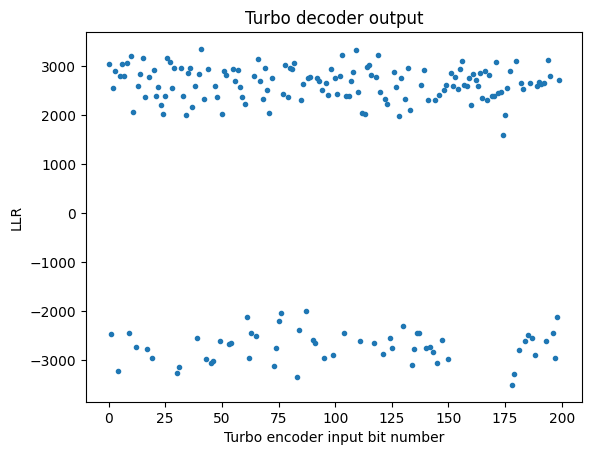

In [28]:
plt.plot(sib1_LLRs, '.')
plt.xlabel('Turbo encoder input bit number')
plt.ylabel('LLR')
plt.title('Turbo decoder output')
plt.show()

In [29]:
pdsch_hard_bytes = np.packbits(sib1_LLRs < 0)

In [30]:
class CRC24A_Table:
    def __init__(self, crc_poly):
        self.crc_poly = crc_poly
        self._t = np.zeros(256, dtype=np.uint32)
        mask = np.uint32(1 << 23)
        for n in np.arange(256, dtype=np.uint32):
            c = n << 16
            for _ in range(8):
                c = (crc_poly ^ (c << 1)) if (c & mask) else (c << 1)
            self._t[n] = c & 0xFFFFFF

    def __call__(self, data):
        crc = np.uint32(0)
        for byte in data:
            crc = ((crc << 8) ^ self._t[((crc >> 16) ^ byte) & 0xFF]) & 0xFFFFFF
        return crc & 0xFFFFFF

In [31]:
crc = CRC24A_Table(0x864CFB)

crc_match = False
if crc(pdsch_hard_bytes) == 0:
    crc_match = True

assert crc_match == True

SIB1_bytes = pdsch_hard_bytes[:-3]
print(f"SIB1 decoded! {len(SIB1_bytes)} bytes")
print(f"First 10 bytes: {SIB1_bytes[:10]}")

SIB1 decoded! 22 bytes
First 10 bytes: [ 72  72  80   3   1  22  70   7  64 120]
